<a href="https://colab.research.google.com/github/vneumannufprbr/TrabajosenPython/blob/main/Escalado_Doble_Verificaci%C3%B3n_PCA_MAD_pEP_DBSCAN_Ok_vf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Archivo 'datos_fusionados_operantes.xlsx' cargado exitosamente.
El dataset tiene 75566 filas y 30 columnas.
--- Iniciando Verificación Temporal con PCA para cada 'etiqueta_padre' ---
Procesando grupo 1/17: EM-E-001
  -> Se usó un multiplicador de 23.96. Se encontraron 47 picos de error de PCA.
Procesando grupo 2/17: EM-E-002
  -> Se usó un multiplicador de 12.32. Se encontraron 138 picos de error de PCA.
Procesando grupo 3/17: EM-E-004
  -> Se usó un multiplicador de 6970.15. Se encontraron 137 picos de error de PCA.
Procesando grupo 4/17: PD-E-006/3
  -> Se usó un multiplicador de 2923.42. Se encontraron 88 picos de error de PCA.
Procesando grupo 5/17: EM-E-003
  -> Se usó un multiplicador de 8000.00. Se encontraron 17 picos de error de PCA.
Procesando grupo 6/17: MV-E-027
  -> Se usó un multiplicador de 8000.00. Se encontraron 1 picos de error de PCA.
Procesando grupo 7/17: PD-E-006/1
  -> Se usó un multiplicador de 5711.02. Se encontraron 30 picos de error de PCA.
Procesando grupo 8

<Figure size 1800x600 with 0 Axes>

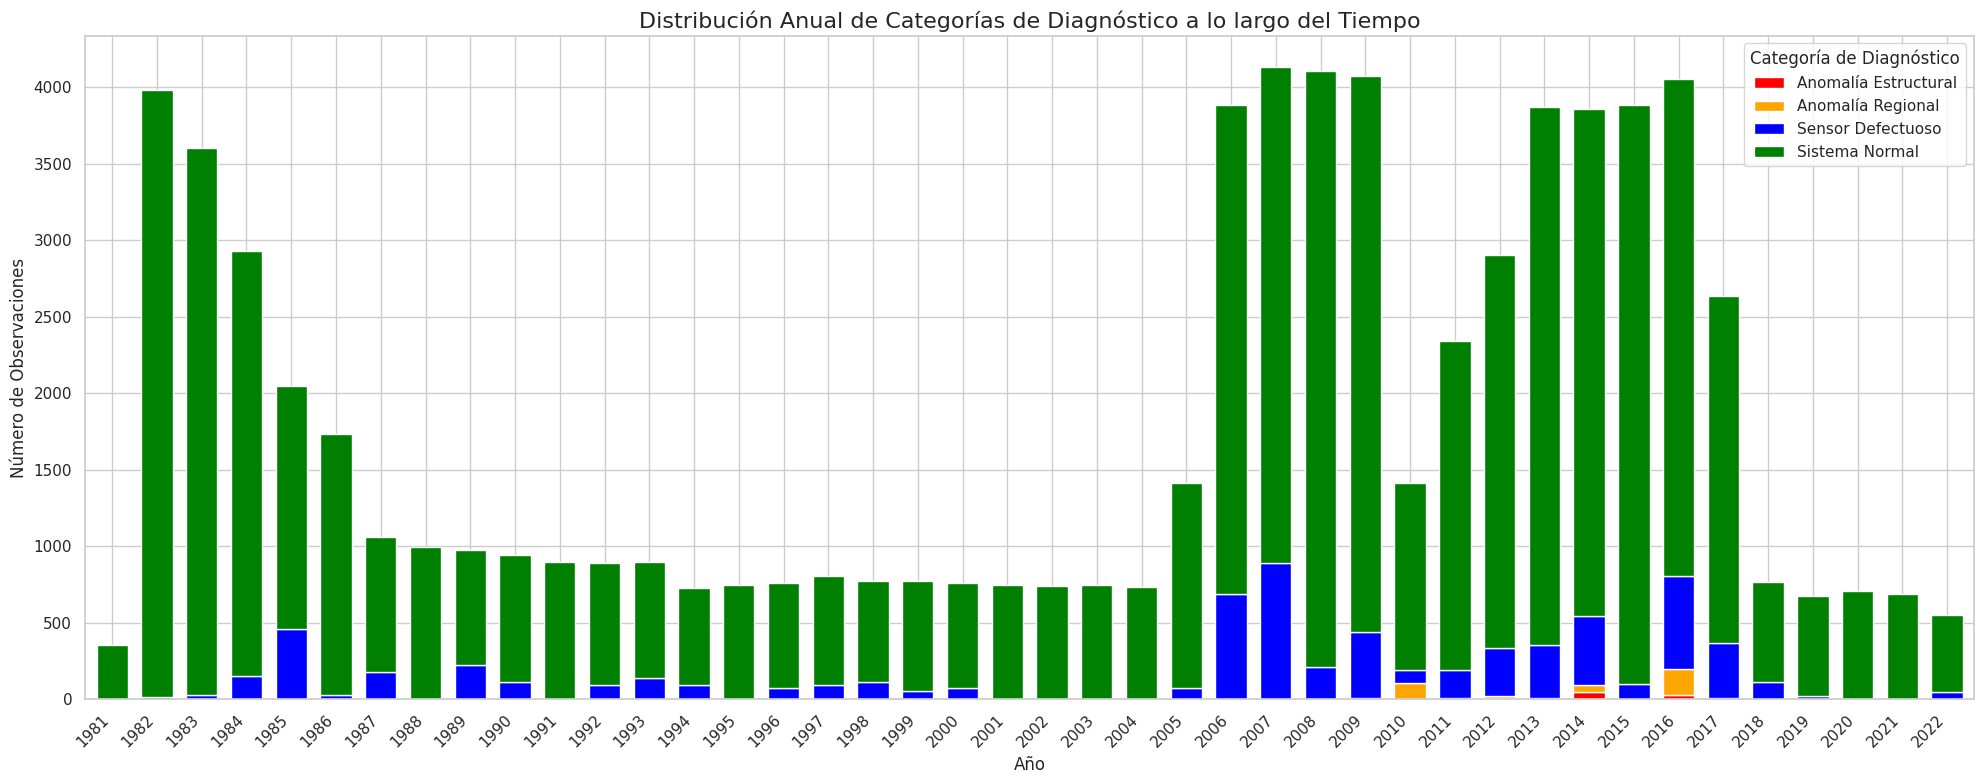


---------------------------------------------------------------------
      Análisis Mensual Detallado de Años con Anomalías Críticas (Estructural o Regional)
---------------------------------------------------------------------

Generando gráfico mensual para el año: 2009


<Figure size 1800x600 with 0 Axes>

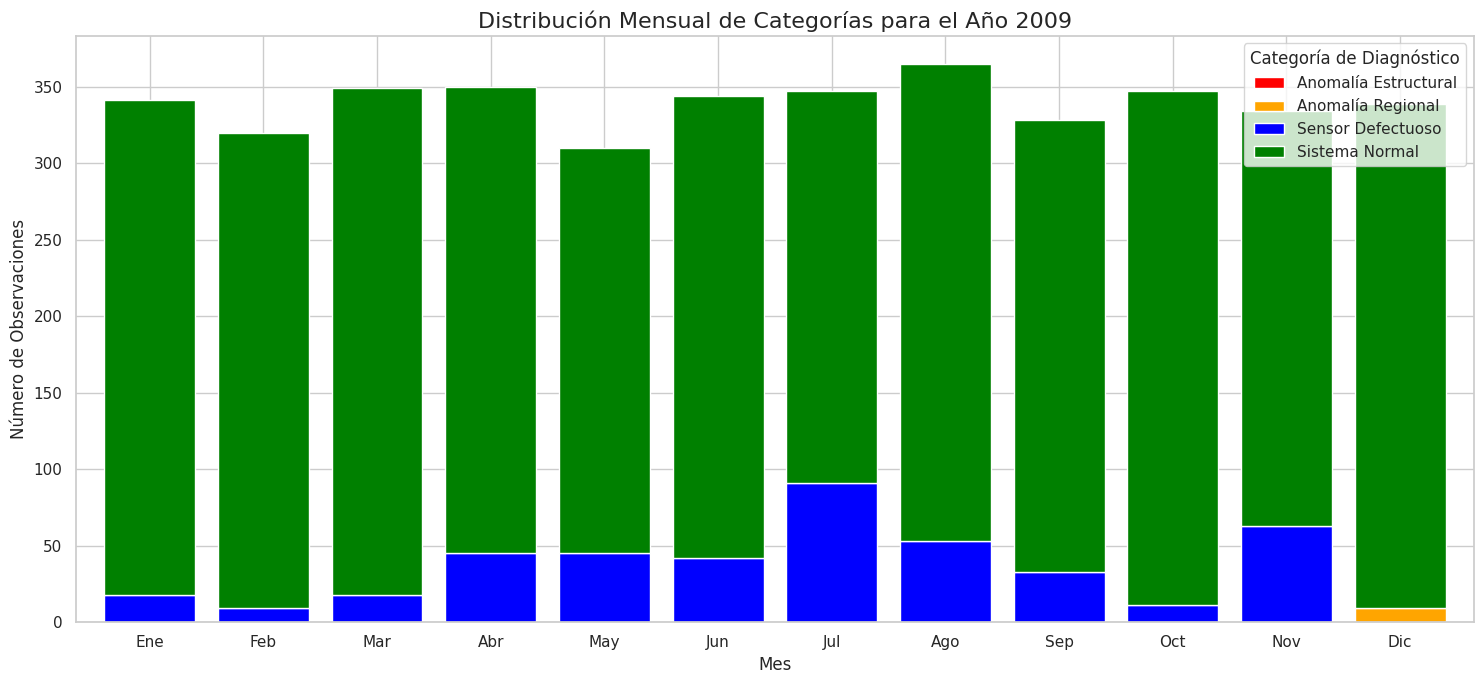


Generando gráfico mensual para el año: 2010


<Figure size 1800x600 with 0 Axes>

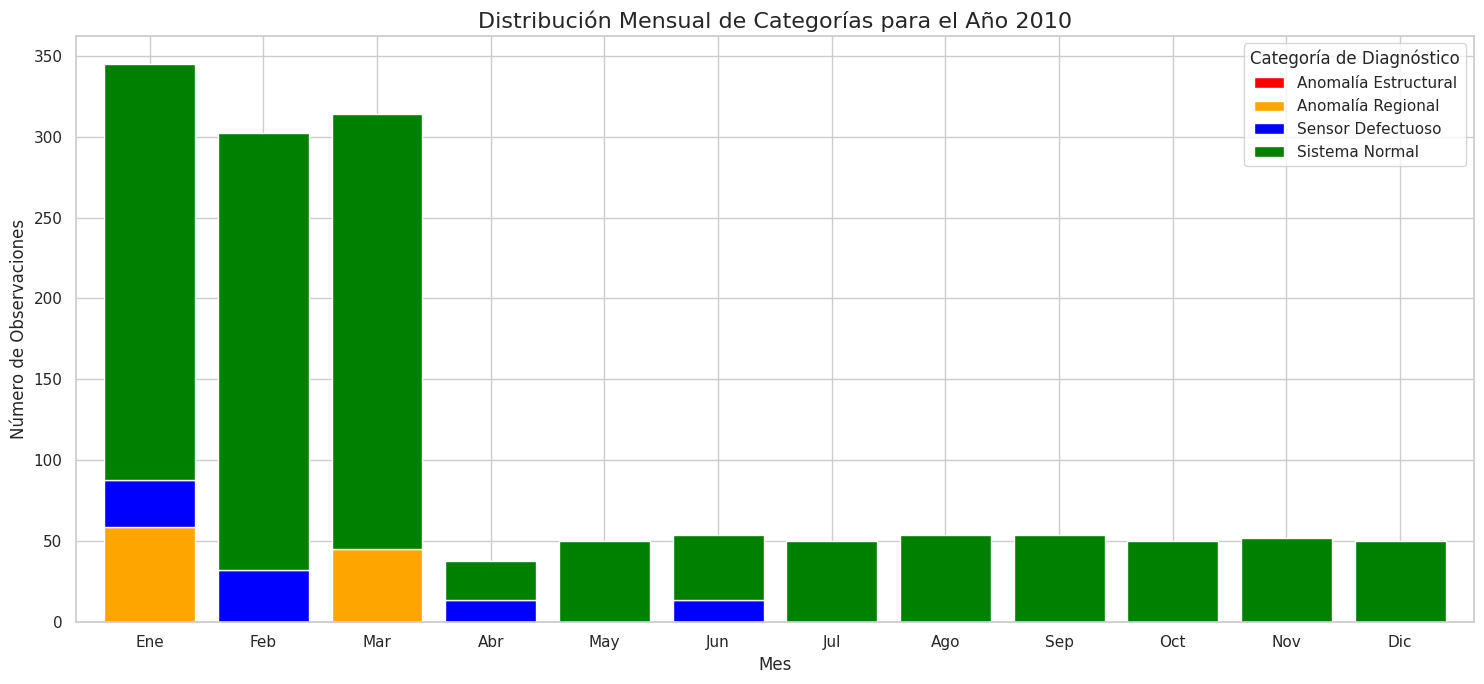


Generando gráfico mensual para el año: 2011


<Figure size 1800x600 with 0 Axes>

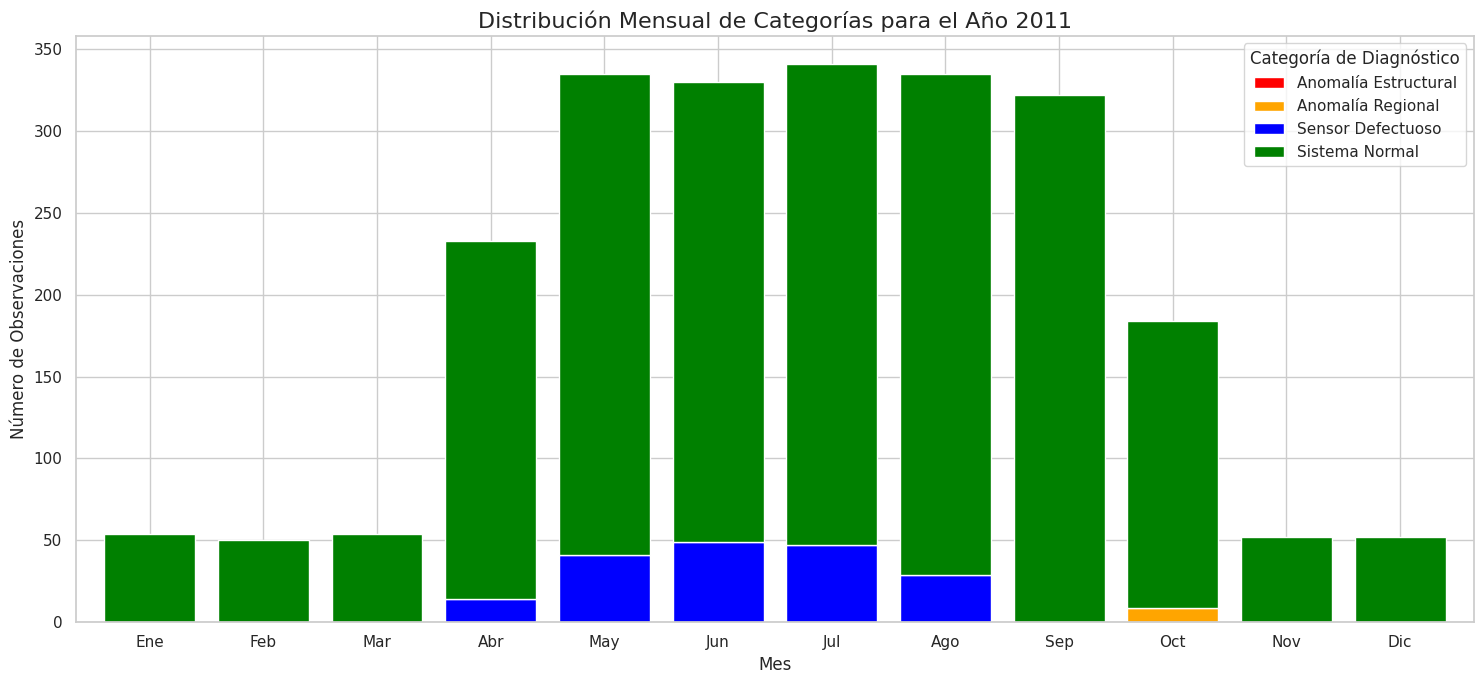


Generando gráfico mensual para el año: 2012


<Figure size 1800x600 with 0 Axes>

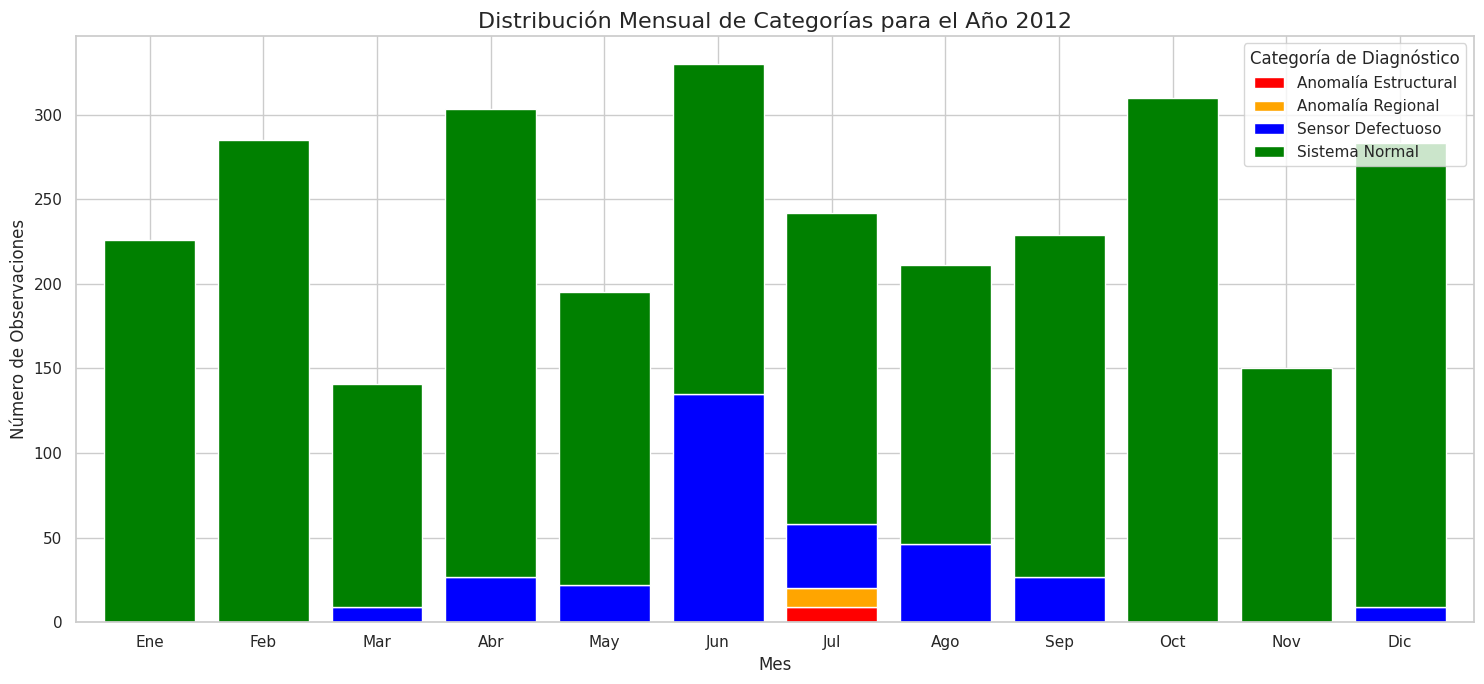


Generando gráfico mensual para el año: 2013


<Figure size 1800x600 with 0 Axes>

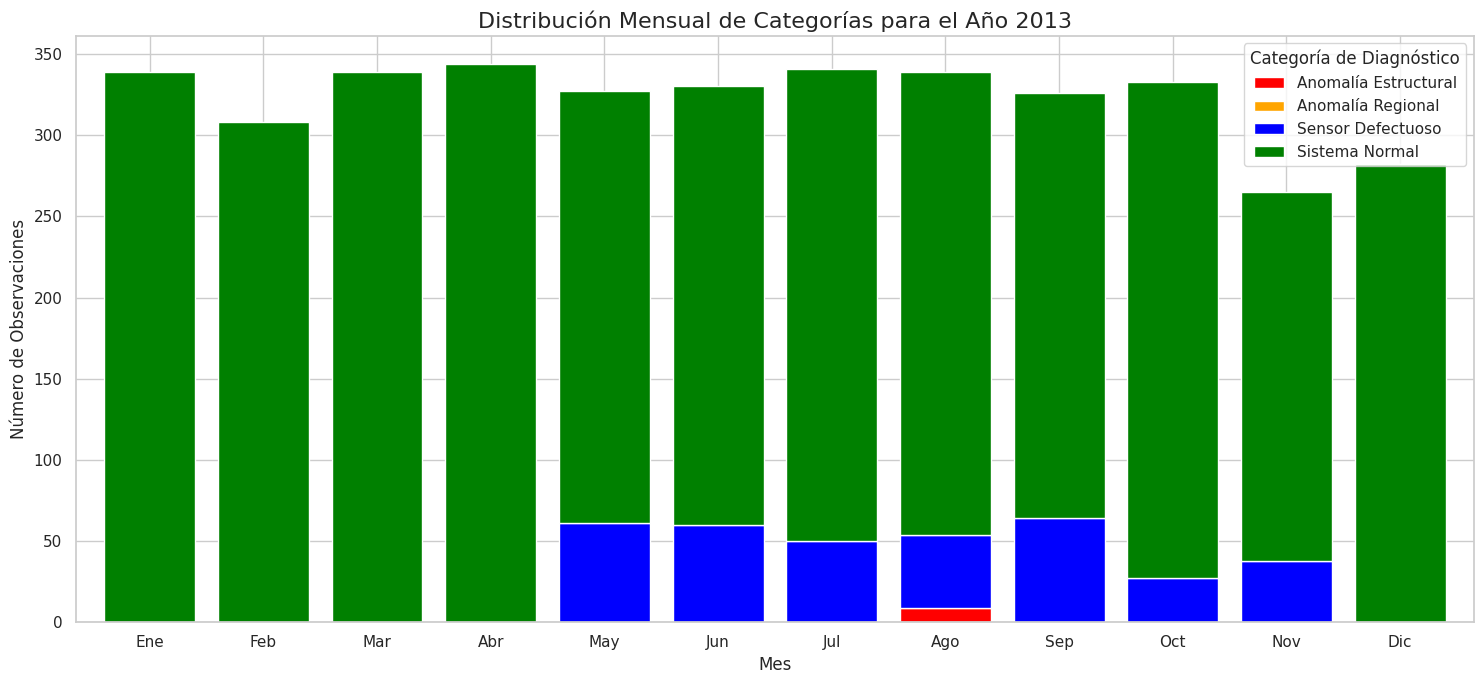


Generando gráfico mensual para el año: 2014


<Figure size 1800x600 with 0 Axes>

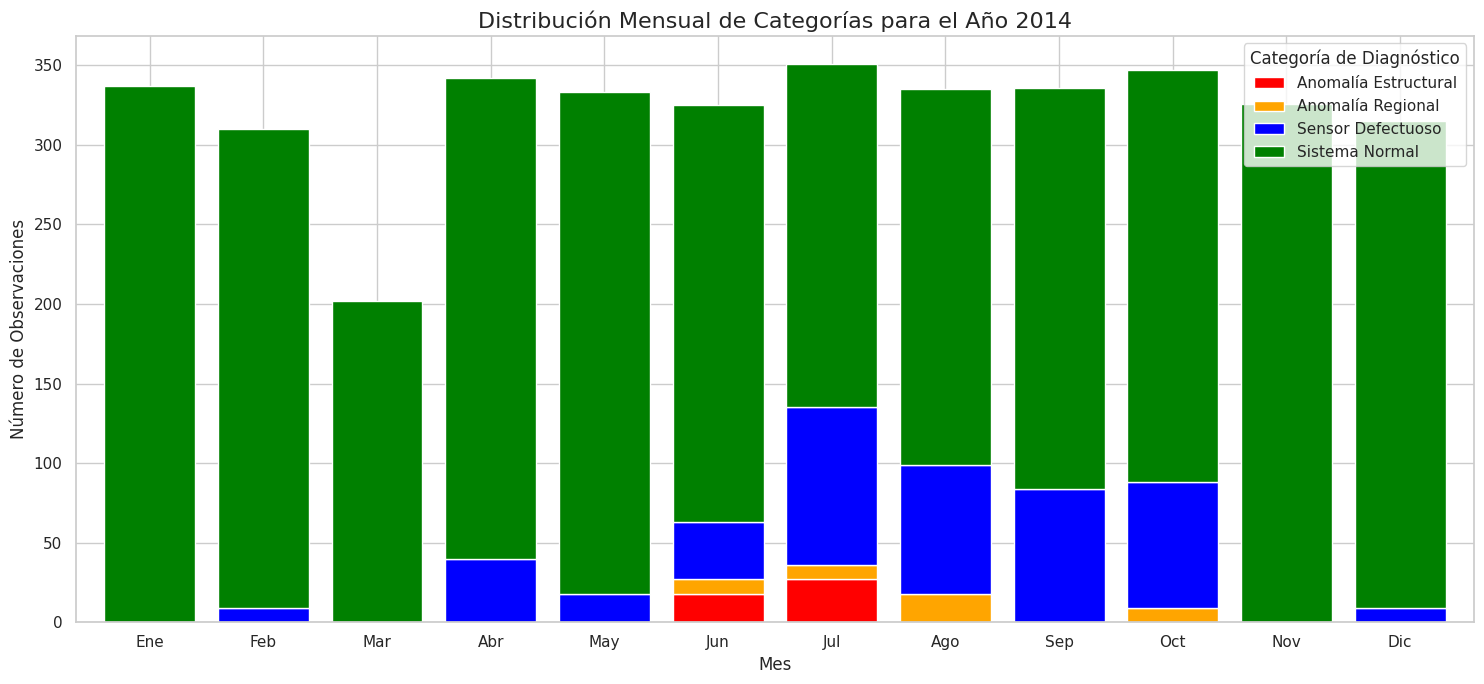


Generando gráfico mensual para el año: 2016


<Figure size 1800x600 with 0 Axes>

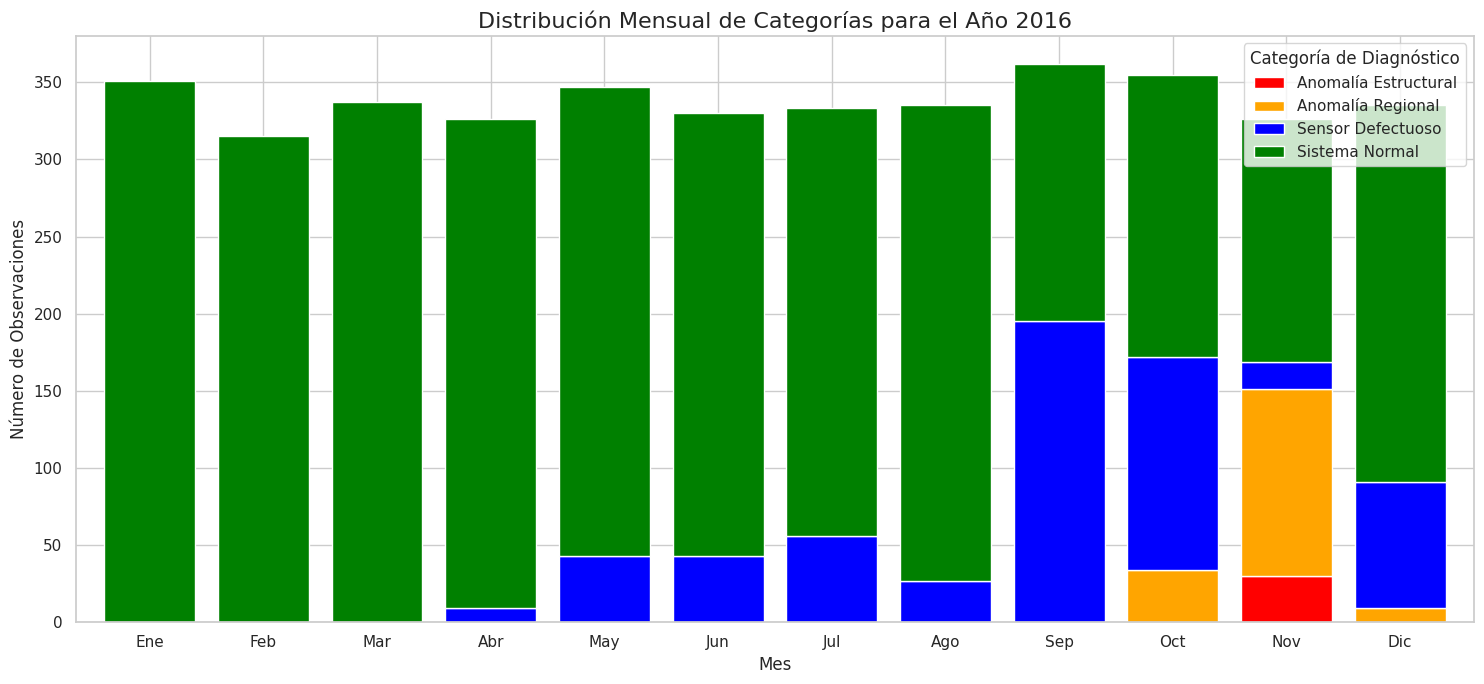


Generando gráfico mensual para el año: 2017


<Figure size 1800x600 with 0 Axes>

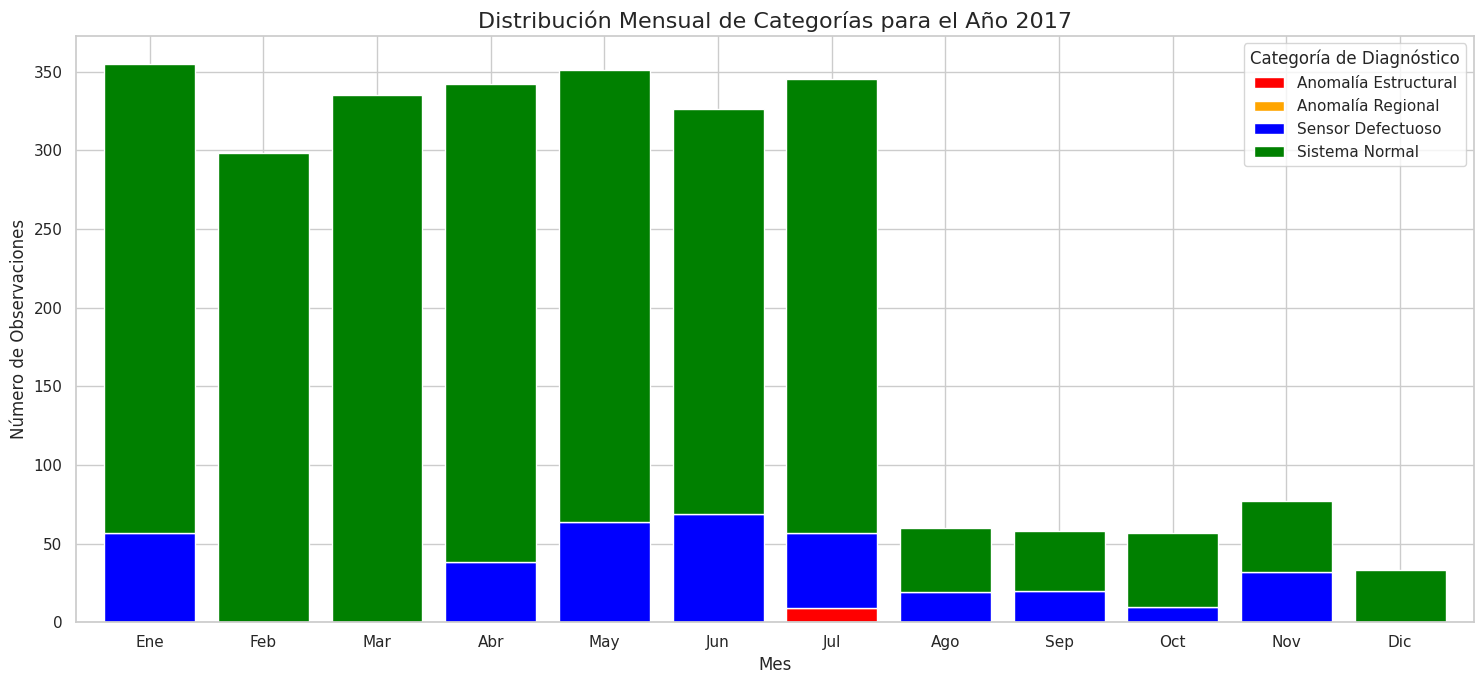


Generando gráfico mensual para el año: 2022


<Figure size 1800x600 with 0 Axes>

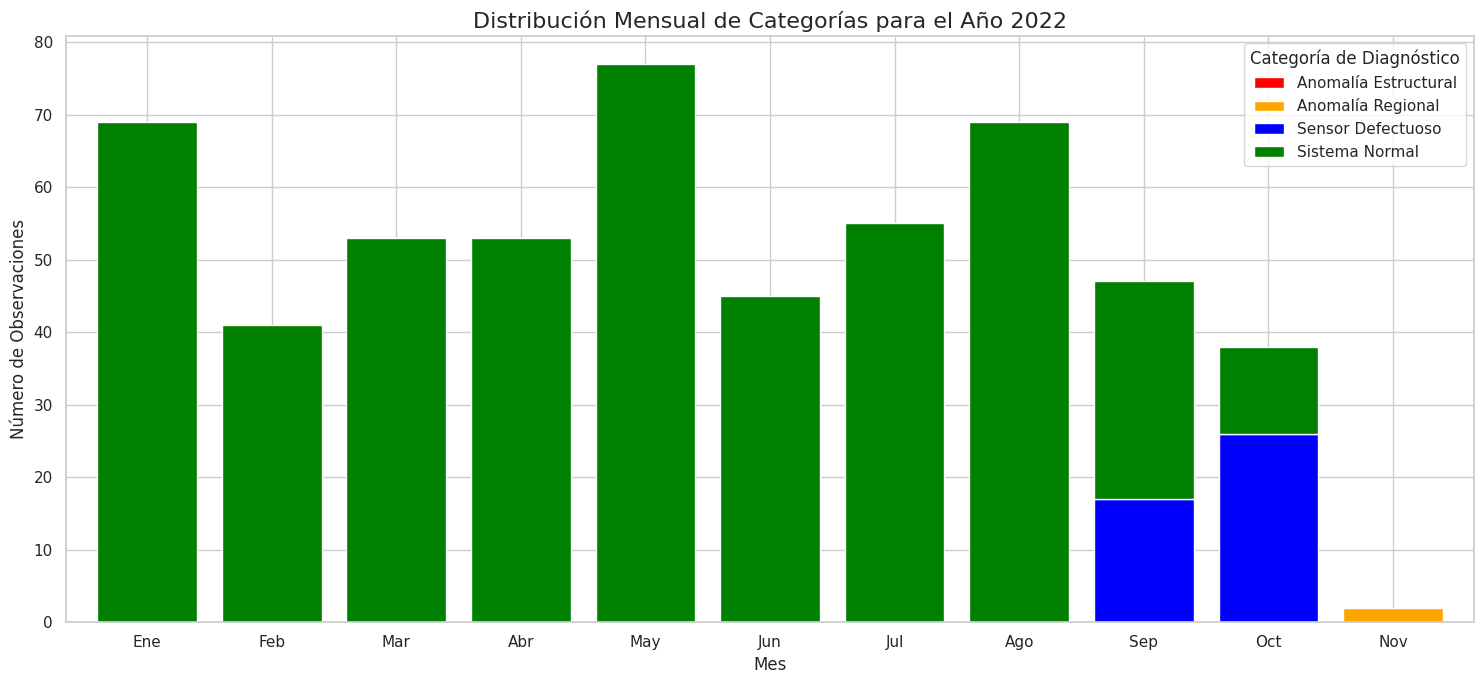


Generando gráfico de distribución por 'etiqueta_padre'...


<Figure size 1800x600 with 0 Axes>

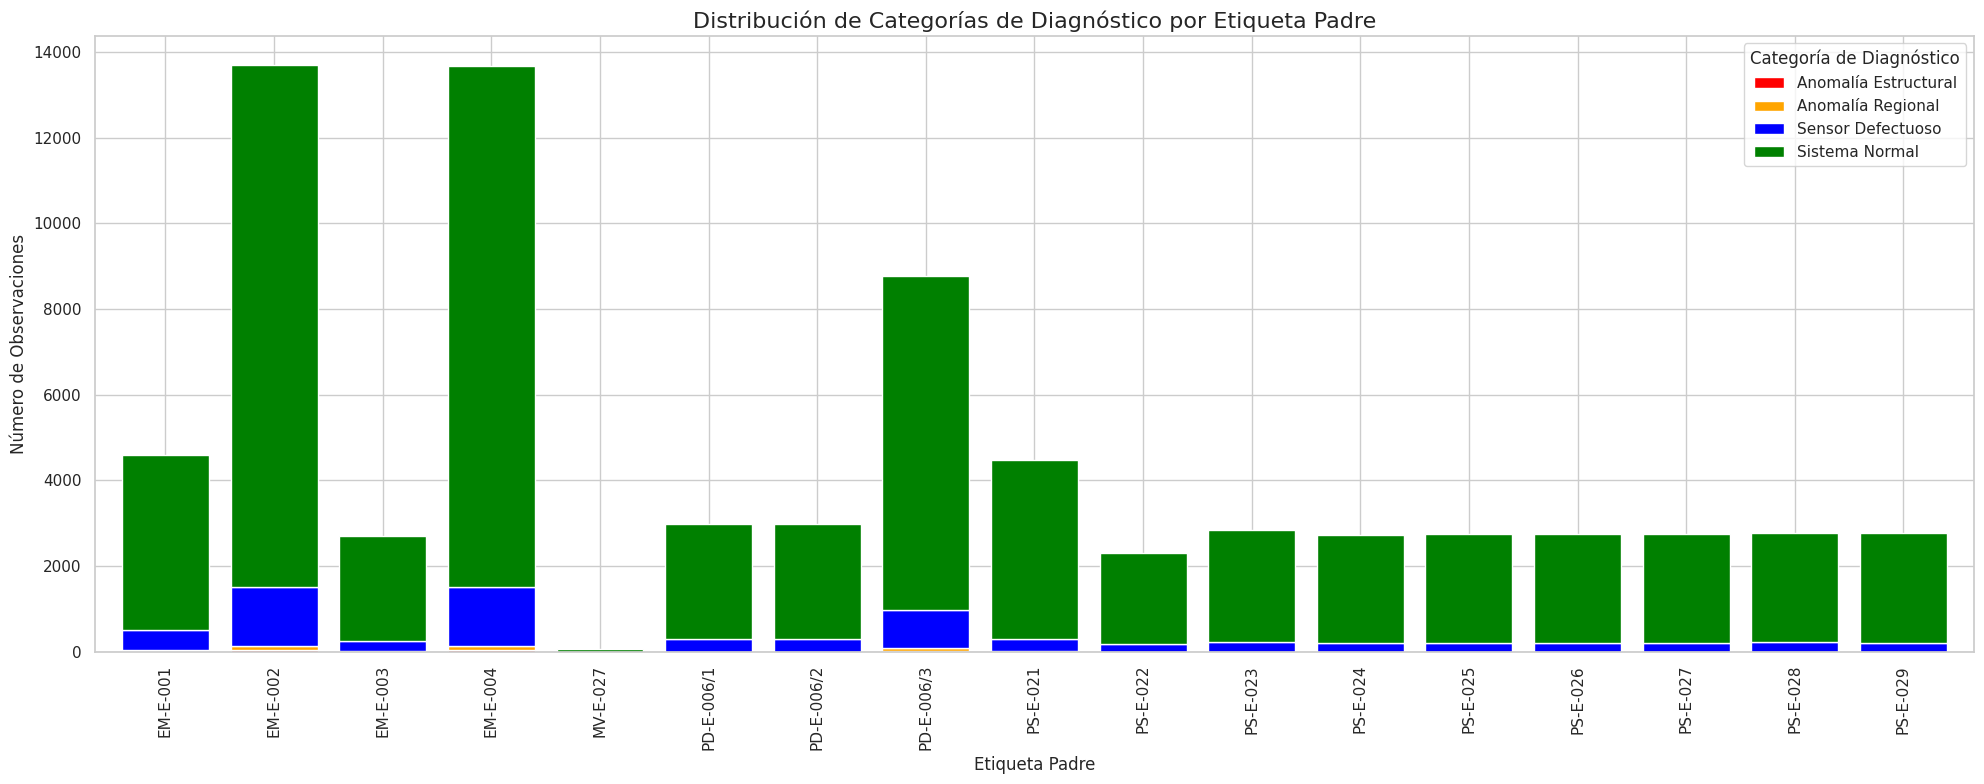


Resultados completos guardados en 'matriz_diagnostico_escalada_completa.xlsx'

--- Visualizando la Distribución Global del Error de Reconstrucción de PCA ---


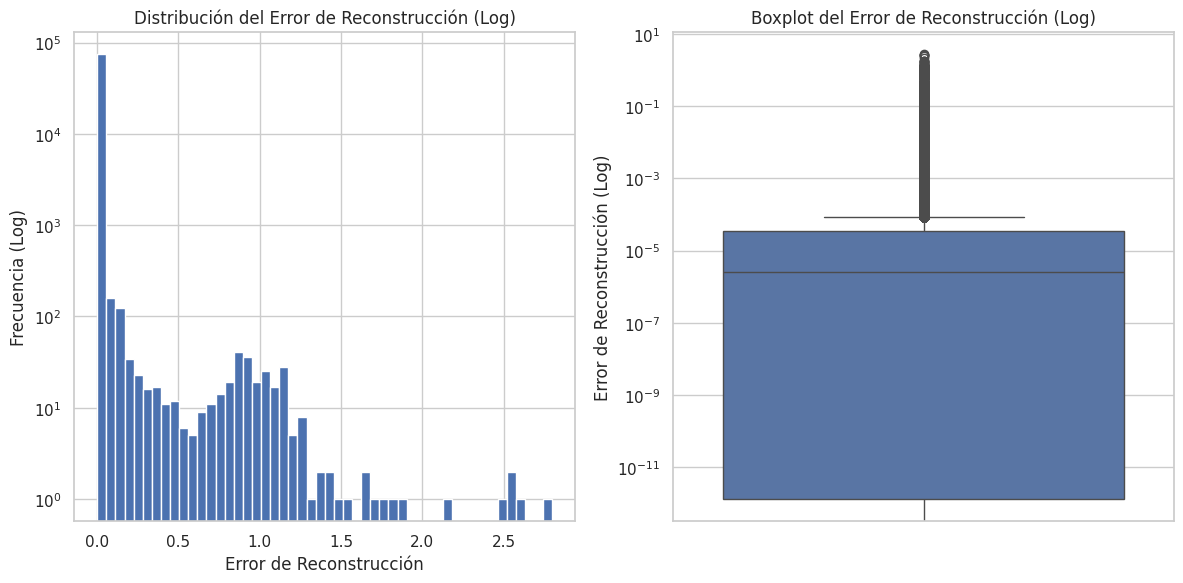


--- Analizando el Error de Reconstrucción por Categoría de Diagnóstico ---


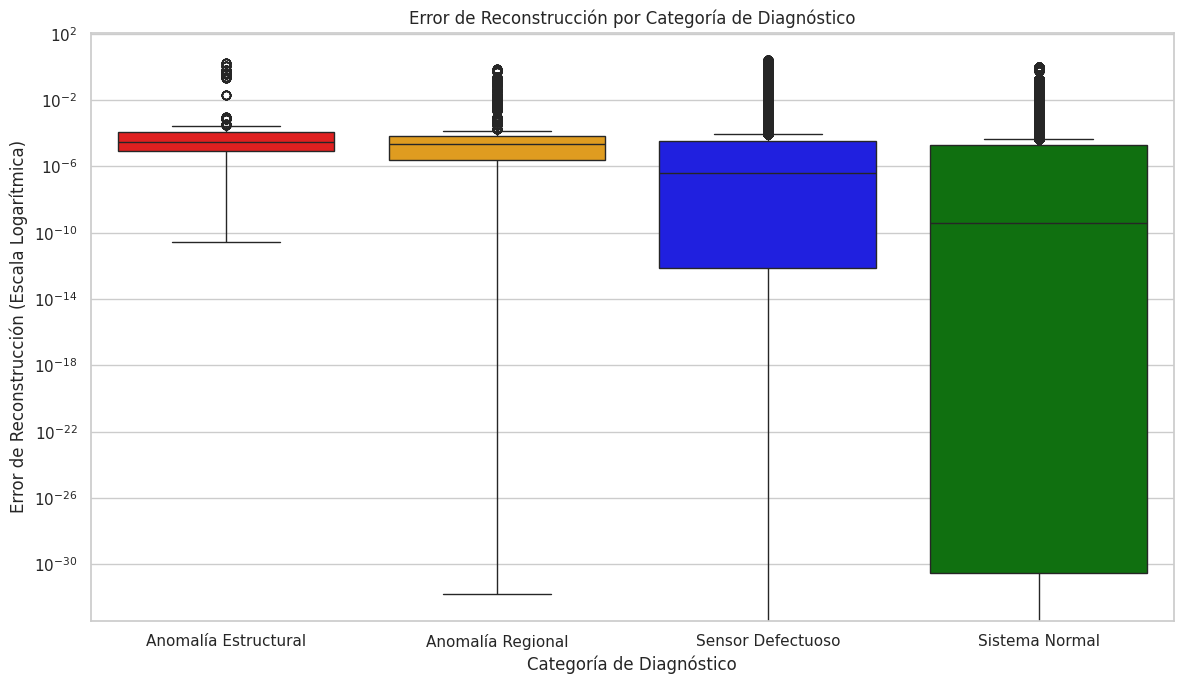


Estadísticas del Error de Reconstrucción por Categoría:
                          count      mean       std           min  \
diagnostic_category                                                 
Anomalía Estructural     1170.0  0.046567  0.209286  2.602727e-11   
Anomalía Regional        4268.0  0.010744  0.059265  1.643460e-32   
Sensor Defectuoso      143447.0  0.016655  0.131702  0.000000e+00   
Sistema Normal        1354975.0  0.000990  0.024924  0.000000e+00   

                               25%           50%       75%       max  
diagnostic_category                                                   
Anomalía Estructural  9.011454e-06  3.135133e-05  0.000123  1.765773  
Anomalía Regional     2.502269e-06  2.161032e-05  0.000070  0.723251  
Sensor Defectuoso     8.042698e-13  3.863731e-07  0.000035  2.800010  
Sistema Normal        3.122574e-31  3.968027e-10  0.000019  0.957789  

--- Cálculo de Estadísticas Globales del Error de Reconstrucción ---
Mediana Global del Error de Reco

In [3]:
# ==============================================================================
# Celda 1: Importación de Librerías y Carga de Datos
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import warnings

# --- Configuraciones ---
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 6)
warnings.filterwarnings('ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None

# --- Carga de Datos ---
try:
    file_path = 'datos_fusionados_operantes.xlsx'
    df_sensores = pd.read_excel(file_path)
    if 'fecha' in df_sensores.columns:
        df_sensores['fecha'] = pd.to_datetime(df_sensores['fecha'])
        df_sensores.set_index('fecha', inplace=True)
    print("Archivo 'datos_fusionados_operantes.xlsx' cargado exitosamente.")
    print(f"El dataset tiene {df_sensores.shape[0]} filas y {df_sensores.shape[1]} columnas.")
except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no se encontró.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

# ==============================================================================
# Celda 2: Verificación Temporal con PCA (CON MULTIPLICADORES INDIVIDUALES)
# ==============================================================================
print("--- Iniciando Verificación Temporal con PCA para cada 'etiqueta_padre' ---")

# Conjunto para almacenar todas las fechas identificadas como anómalas por PCA
pca_anomalies_indices = set()
# DataFrame para almacenar todos los errores de reconstrucción con su etiqueta
all_reconstruction_errors = pd.DataFrame(columns=['reconstruction_error', 'etiqueta_padre'])

# --- Diccionario de Multiplicadores para cada etiqueta_padre ---
# Rellenado con los valores del percentil 99% de tu análisis.
multipliers_por_etiqueta = {
    'EM-E-001': 23.96,
    'EM-E-002': 12.32,
    'EM-E-004': 6970.15,
    'PD-E-006/3': 2923.42,
    'PD-E-006/1': 5711.02,
    'PD-E-006/2': 11384.80,
    # Las etiquetas con MAD=0 usarán el multiplicador por defecto.
}
default_mad_multiplier = 20000.0 # Valor para etiquetas no listadas arriba

# Limpiar espacios en blanco de 'etiqueta_padre' antes de obtener los valores únicos
df_sensores['etiqueta_padre'] = df_sensores['etiqueta_padre'].str.strip()
parent_labels = df_sensores['etiqueta_padre'].dropna().unique()

for i, label in enumerate(parent_labels):
    print(f"Procesando grupo {i+1}/{len(parent_labels)}: {label}")
    df_grupo = df_sensores[df_sensores['etiqueta_padre'] == label]

    numeric_cols = df_grupo.select_dtypes(include=np.number).columns.tolist()
    cols_to_exclude = ['coordenada_norte', 'coordenada_este', 'Elevación', 'nivel_embalse']
    numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude and df_grupo[col].nunique() > 1]

    if len(numeric_cols) < 2:
        print(f"  -> Grupo omitido: no tiene suficientes columnas numéricas.")
        continue

    df_numeric = df_grupo[numeric_cols].dropna()

    if len(df_numeric) < 5:
        print(f"  -> Grupo omitido: no tiene suficientes datos.")
        continue

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_numeric)
    pca = PCA(n_components=0.95)
    transformed_data = pca.fit_transform(scaled_data)
    reconstructed_data = pca.inverse_transform(transformed_data)

    reconstruction_error = np.mean((scaled_data - reconstructed_data)**2, axis=1)

    df_error = pd.DataFrame({'reconstruction_error': reconstruction_error}, index=df_numeric.index)
    df_error['etiqueta_padre'] = label
    all_reconstruction_errors = pd.concat([all_reconstruction_errors, df_error])

    mad_multiplier = multipliers_por_etiqueta.get(label, default_mad_multiplier)

    median_error = df_error['reconstruction_error'].median()
    mad_error = np.median(np.abs(df_error['reconstruction_error'] - median_error))

    if mad_error > 1e-9:
        threshold_mad = median_error + mad_multiplier * mad_error
    else:
        threshold_mad = df_error['reconstruction_error'].quantile(0.99)

    peak_indices = df_error[df_error['reconstruction_error'] > threshold_mad].index
    pca_anomalies_indices.update(peak_indices)
    print(f"  -> Se usó un multiplicador de {mad_multiplier:.2f}. Se encontraron {len(peak_indices)} picos de error de PCA.")

print(f"\nVerificación Temporal completada. Total de fechas únicas con anomalías PCA: {len(pca_anomalies_indices)}")


# ==============================================================================
# Celda 3: Verificación Espacial con DBSCAN
# ==============================================================================
print("\n--- Iniciando Verificación Espacial con DBSCAN para cada 'local_geologico' ---")
dbscan_noise_indices = set()
features_for_dbscan = ['valor_promedio', 'valor_minimo', 'valor_maximo']
df_dbscan_analysis = df_sensores.dropna(subset=features_for_dbscan)
df_dbscan_analysis['local_geologico'] = df_dbscan_analysis['local_geologico'].str.strip()
geolocations = df_dbscan_analysis['local_geologico'].dropna().unique()

for i, location in enumerate(geolocations):
    print(f"Procesando ubicación {i+1}/{len(geolocations)}: {location}")
    df_location = df_dbscan_analysis[df_dbscan_analysis['local_geologico'] == location]
    if len(df_location) < 5:
        print(f"  -> Ubicación omitida: no tiene suficientes datos.")
        continue
    scaled_data = StandardScaler().fit_transform(df_location[features_for_dbscan])
    dbscan = DBSCAN(eps=0.7, min_samples=4)
    labels = dbscan.fit_predict(scaled_data)
    df_location['dbscan_label'] = labels
    noise_indices = df_location[df_location['dbscan_label'] == -1].index
    dbscan_noise_indices.update(noise_indices)
    print(f"  -> Se encontraron {len(noise_indices)} puntos de ruido.")

print(f"\nVerificación Espacial completada. Total de fechas únicas con ruido DBSCAN: {len(dbscan_noise_indices)}")


# ==============================================================================
# Celda 4: Implementación de la Matriz de Diagnóstico
# ==============================================================================
print("\n--- Aplicando la Matriz de Diagnóstico a todo el dataset ---")
def classify_observation(date_index):
    is_pca_anomaly = date_index in pca_anomalies_indices
    is_dbscan_noise = date_index in dbscan_noise_indices
    if is_pca_anomaly and is_dbscan_noise: return 'Anomalía Estructural'
    elif is_pca_anomaly and not is_dbscan_noise: return 'Sensor Defectuoso'
    elif not is_pca_anomaly and is_dbscan_noise: return 'Anomalía Regional'
    else: return 'Sistema Normal'
df_sensores['diagnostic_category'] = [classify_observation(date) for date in df_sensores.index]
print("Clasificación de diagnóstico completada.")


# ==============================================================================
# Celda 5: Análisis y Visualización de Resultados (COMPLETA)
# ==============================================================================
print("\n=========================================================")
print("         Resultados de la Matriz de Diagnóstico")
print("=========================================================")

color_map = {'Anomalía Estructural': 'red', 'Anomalía Regional': 'orange', 'Sensor Defectuoso': 'blue', 'Sistema Normal': 'green'}
category_order = list(color_map.keys())

# --- 1.A. Distribución General de Categorías ---
print("\nDistribución General de observaciones por categoría de diagnóstico:")
category_counts = df_sensores['diagnostic_category'].value_counts()
category_percentages = df_sensores['diagnostic_category'].value_counts(normalize=True) * 100
summary_df = pd.DataFrame({'Conteo': category_counts, 'Porcentaje (%)': category_percentages})
print(summary_df)

# --- 1.B. Distribución por Etiqueta Padre ---
print("\n---------------------------------------------------------")
print("      Distribución de Diagnóstico por Etiqueta Padre")
print("---------------------------------------------------------")
parent_labels_in_results = df_sensores['etiqueta_padre'].dropna().unique()
for label in sorted(parent_labels_in_results):
    print(f"\n--- Resumen para: {label.strip()} ---")
    df_label_specific = df_sensores[df_sensores['etiqueta_padre'] == label]
    label_counts = df_label_specific['diagnostic_category'].value_counts()
    if label_counts.empty:
        print("No hay datos de diagnóstico para este grupo.")
        continue
    label_percentages = df_label_specific['diagnostic_category'].value_counts(normalize=True) * 100
    summary_label_df = pd.DataFrame({'Conteo': label_counts, 'Porcentaje (%)': label_percentages})
    print(summary_label_df)

# --- 2. Visualización: Distribución Temporal (Anual) ---
print("\nGenerando gráfico de distribución anual de categorías...")
df_time_category = df_sensores.groupby([df_sensores.index, 'diagnostic_category']).size().unstack(fill_value=0)
df_time_category_yearly = df_time_category.resample('Y').sum()

for cat in category_order:
    if cat not in df_time_category_yearly.columns:
        df_time_category_yearly[cat] = 0
df_time_category_yearly = df_time_category_yearly[category_order]

plt.figure()
df_time_category_yearly.plot(kind='bar', stacked=True, figsize=(20, 8), color=color_map.values(), width=0.7)
plt.title("Distribución Anual de Categorías de Diagnóstico a lo largo del Tiempo", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Número de Observaciones", fontsize=12)
plt.legend(title="Categoría de Diagnóstico")
tick_labels = [item.strftime('%Y') for item in df_time_category_yearly.index]
plt.gca().set_xticklabels(tick_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3. Visualización Detallada: Años con Anomalías Críticas ---
print("\n---------------------------------------------------------------------")
print("      Análisis Mensual Detallado de Años con Anomalías Críticas (Estructural o Regional)")
print("---------------------------------------------------------------------")

structural_anomalies_df = df_sensores[df_sensores['diagnostic_category'] == 'Anomalía Estructural']
years_with_structural = structural_anomalies_df.index.year.unique()
regional_anomalies_df = df_sensores[df_sensores['diagnostic_category'] == 'Anomalía Regional']
years_with_regional = regional_anomalies_df.index.year.unique()
critical_years = sorted(list(set(years_with_structural) | set(years_with_regional)))

if not any(critical_years):
    print("No se encontraron años con 'Anomalía Estructural' o 'Anomalía Regional' para un análisis detallado.")
else:
    for year in critical_years:
        print(f"\nGenerando gráfico mensual para el año: {year}")
        df_year = df_sensores[df_sensores.index.year == year]
        df_monthly = df_year.groupby([df_year.index.month, 'diagnostic_category']).size().unstack(fill_value=0)
        for cat in category_order:
            if cat not in df_monthly.columns:
                df_monthly[cat] = 0
        df_monthly = df_monthly[category_order]

        plt.figure()
        df_monthly.plot(kind='bar', stacked=True, figsize=(15, 7), color=color_map.values(), width=0.8)
        plt.title(f"Distribución Mensual de Categorías para el Año {year}", fontsize=16)
        plt.xlabel("Mes", fontsize=12)
        plt.ylabel("Número de Observaciones", fontsize=12)
        plt.legend(title="Categoría de Diagnóstico")
        meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
        plt.gca().set_xticklabels([meses[i-1] for i in df_monthly.index], rotation=0)
        plt.tight_layout()
        plt.show()

# --- 4. Visualización: Distribución por Etiqueta Padre ---
print("\nGenerando gráfico de distribución por 'etiqueta_padre'...")
df_label_category = df_sensores.groupby(['etiqueta_padre', 'diagnostic_category']).size().unstack(fill_value=0)
for cat in category_order:
    if cat not in df_label_category.columns:
        df_label_category[cat] = 0
df_label_category = df_label_category[category_order]

plt.figure()
df_label_category.plot(kind='bar', stacked=True, figsize=(20, 8), color=color_map.values(), width=0.8)
plt.title("Distribución de Categorías de Diagnóstico por Etiqueta Padre", fontsize=16)
plt.xlabel("Etiqueta Padre", fontsize=12)
plt.ylabel("Número de Observaciones", fontsize=12)
plt.legend(title="Categoría de Diagnóstico")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# --- 5. Guardar resultados ---
output_filename = "matriz_diagnostico_escalada_completa.xlsx"
df_sensores.to_excel(output_filename)
print(f"\nResultados completos guardados en '{output_filename}'")


# ==============================================================================
# Celda 6: Visualización de la Distribución del Error de Reconstrucción de PCA
# ==============================================================================
print("\n--- Visualizando la Distribución Global del Error de Reconstrucción de PCA ---")
if not all_reconstruction_errors.empty:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(all_reconstruction_errors['reconstruction_error'], bins=50)
    plt.yscale('log')
    plt.title("Distribución del Error de Reconstrucción (Log)")
    plt.xlabel("Error de Reconstrucción")
    plt.ylabel("Frecuencia (Log)")

    plt.subplot(1, 2, 2)
    sns.boxplot(y=all_reconstruction_errors['reconstruction_error'])
    plt.title("Boxplot del Error de Reconstrucción (Log)")
    plt.ylabel("Error de Reconstrucción (Log)")
    plt.yscale('log')
    plt.tight_layout()
    plt.show()
else:
    print("El DataFrame 'all_reconstruction_errors' está vacío.")

# ==============================================================================
# Celda 7: Análisis del Error de Reconstrucción por Categoría de Diagnóstico
# ==============================================================================
print("\n--- Analizando el Error de Reconstrucción por Categoría de Diagnóstico ---")
df_aligned = df_sensores.join(all_reconstruction_errors['reconstruction_error'], how='inner')

if not df_aligned.empty:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='diagnostic_category', y='reconstruction_error', data=df_aligned, palette=color_map, order=category_order)
    plt.yscale('log')
    plt.title("Error de Reconstrucción por Categoría de Diagnóstico")
    plt.xlabel("Categoría de Diagnóstico")
    plt.ylabel("Error de Reconstrucción (Escala Logarítmica)")
    plt.tight_layout()
    plt.show()

    print("\nEstadísticas del Error de Reconstrucción por Categoría:")
    print(df_aligned.groupby('diagnostic_category')['reconstruction_error'].describe())
else:
    print("Error: No se pudo alinear el DataFrame de diagnóstico con los errores.")

# ==============================================================================
# Celda 8: Calcular el MAD Global del Error de Reconstrucción
# ==============================================================================
print("\n--- Cálculo de Estadísticas Globales del Error de Reconstrucción ---")
if not all_reconstruction_errors.empty:
    median_error_global = all_reconstruction_errors['reconstruction_error'].median()
    mad_error_global = np.median(np.abs(all_reconstruction_errors['reconstruction_error'] - median_error_global))
    print(f"Mediana Global del Error de Reconstrucción: {median_error_global}")
    print(f"MAD Global del Error de Reconstrucción: {mad_error_global}")
else:
    print("El DataFrame de errores está vacío.")

# ==============================================================================
# Celda 9: CÁLCULO DE mad_multiplier PARA CADA ETIQUETA_PADRE
# ==============================================================================
print("\n--- Calculando mad_multiplier para diferentes percentiles POR CADA ETIQUETA_PADRE ---")

if all_reconstruction_errors.empty:
    print("El DataFrame 'all_reconstruction_errors' está vacío. La Celda 2 debe ejecutarse primero.")
else:
    labels_in_errors = all_reconstruction_errors['etiqueta_padre'].unique()

    for label in labels_in_errors:
        print(f"\n--- Análisis de Calibración para: {label} ---")

        df_error_label = all_reconstruction_errors[all_reconstruction_errors['etiqueta_padre'] == label]

        median_error = df_error_label['reconstruction_error'].median()
        mad_error = np.median(np.abs(df_error_label['reconstruction_error'] - median_error))

        print(f"Mediana del Error: {median_error:.6f}")
        print(f"MAD del Error:     {mad_error:.6f}")

        if mad_error < 1e-9:
            print("  -> El MAD del Error de Reconstrucción es cero o muy pequeño. No se puede calcular el mad_multiplier.")
            continue

        percentiles = [0.75, 0.90, 0.95, 0.99]
        error_percentiles = df_error_label['reconstruction_error'].quantile(percentiles)

        print("\nValores de mad_multiplier sugeridos para esta etiqueta:")

        for p in percentiles:
            percentile_value = error_percentiles[p]
            mad_multiplier_p = (percentile_value - median_error) / mad_error
            print(f"  -> Para umbral en Percentil {int(p*100)}% (error={percentile_value:.6f}): mad_multiplier = {mad_multiplier_p:.2f}")

        print("\nCopia y pega el valor de 'mad_multiplier' que elijas en el diccionario de la Celda 2.")